# 01 — ThoughtTrace EDA

**Questions this notebook answers**

1. How big is the corpus? (users, conversations, total thought annotations)
2. How are conversations distributed across users?
3. How long are conversations (in turns)?
4. How many thought annotations does a conversation carry?
5. What is the reaction-category (5) and reason-category (7) distribution, as counts and proportions?
6. How does the corpus break down by source LLM (~20) and by topic domain?
7. **How sparse is the supervision signal?** How many conversations are very short or carry only a single reaction signal, and what fraction of the corpus is that?

This is exploratory: simple, readable, read-only. It loads the dataset directly from the HuggingFace Hub and does not write anything back.

## Data source & label caveat

ThoughtTrace is **not** stored in this repo. It is the HuggingFace dataset
[`SCAI-JHU/ThoughtTrace`](https://huggingface.co/datasets/SCAI-JHU/ThoughtTrace) (split `train`,
~2,155 conversations / 1,058 users / 20 models, Parquet). Set `HF_TOKEN` to silence the
unauthenticated rate-limit warning (loading works without it).

Per-message schema: messages use `type` (`"user"`/`"assistant"`, **not** `role`); `reasons[]`
appear on user turns and `reactions[]` on assistant turns, each `{content, timestamp, label}`.

**Label vocabulary is taken AS RELEASED**, which differs from the dataset README/paper. We
report the labels that actually occur and flag the discrepancy inline in section (e).

In [ ]:
# Minimal EDA stack - exploratory, not production.
import os
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Load the corpus straight from the Hub.
HF_DATASET = "SCAI-JHU/ThoughtTrace"
SPLIT = "train"

ds = load_dataset(HF_DATASET, split=SPLIT, token=os.environ.get("HF_TOKEN"))

print(f"Loaded {len(ds):,} conversations from {HF_DATASET} [{SPLIT}]")
print("\nTop-level fields per conversation record:")
for name in ds.column_names:
    print(f"  - {name}")

Loaded 2,155 conversations from SCAI-JHU/ThoughtTrace [train]

Top-level fields per conversation record:
  - id
  - messages
  - model_name
  - model_provider
  - created_at
  - updated_at
  - task_summary
  - task_expectation
  - survey_answers


In [ ]:
# --- Helpers ---------------------------------------------------------------

def normalize_label(label):
    # Released labels vary in case/spacing; normalize before counting.
    return label.strip().lower().replace(" ", "_").replace("-", "_")

def parse_conv_id(conv_id):
    # ids look like "user1016_task1_conversation1" -> (user, task, seq)
    user = task = seq = None
    for part in conv_id.split("_"):
        if part.startswith("user"):
            user = part
        elif part.startswith("task"):
            task = part
        elif part.startswith("conversation"):
            seq = part
    return user, task, seq

# --- Flatten into per-conversation rows + per-annotation label lists --------

conv_rows = []
reason_labels = []     # one entry per reason annotation (user turns)
reaction_labels = []   # one entry per reaction annotation (assistant turns)

for rec in ds:
    messages = rec.get("messages") or []
    user_turns = [m for m in messages if m.get("type") == "user"]
    asst_turns = [m for m in messages if m.get("type") == "assistant"]

    rec_reasons = [r for m in user_turns for r in (m.get("reasons") or [])]
    rec_reactions = [r for m in asst_turns for r in (m.get("reactions") or [])]

    reason_labels.extend(normalize_label(r["label"]) for r in rec_reasons if r.get("label"))
    reaction_labels.extend(normalize_label(r["label"]) for r in rec_reactions if r.get("label"))

    user_id, task_id, _ = parse_conv_id(rec.get("id", ""))
    conv_rows.append({
        "conv_id": rec.get("id"),
        "user_id": user_id,
        "task_id": task_id,
        "model_name": rec.get("model_name"),
        "model_provider": rec.get("model_provider"),
        "n_messages": len(messages),
        "n_user_turns": len(user_turns),
        "n_assistant_turns": len(asst_turns),
        "n_reasons": len(rec_reasons),
        "n_reactions": len(rec_reactions),
        "n_thought_annotations": len(rec_reasons) + len(rec_reactions),
    })

conv = pd.DataFrame(conv_rows)
conv.head()

,conv_id,user_id,task_id,model_name,model_provider,n_messages,n_user_turns,n_assistant_turns,n_reasons,n_reactions,n_thought_annotations
0,user1_task1_conversation1,user1,task1,GPT-5.4,OpenAI,4,2,2,2,1,3
1,user1_task2_conversation1,user1,task2,GPT-5.4,OpenAI,2,1,1,1,1,2
2,user2_task1_conversation1,user2,task1,GPT-5.4,OpenAI,2,1,1,1,1,2
3,user2_task2_conversation1,user2,task2,GPT-5.4,OpenAI,2,1,1,1,1,2
4,user3_task1_conversation1,user3,task1,GPT-5.4,OpenAI,22,11,11,1,6,7


In [ ]:
# (a) Corpus size: users, conversations, total thought annotations.
n_conversations = len(conv)
n_users = conv["user_id"].nunique()
n_models = conv["model_name"].nunique()
total_reasons = int(conv["n_reasons"].sum())
total_reactions = int(conv["n_reactions"].sum())

summary = pd.DataFrame({
    "metric": ["conversations", "unique users", "unique models",
               "reason annotations", "reaction annotations", "total thought annotations"],
    "count": [n_conversations, n_users, n_models,
              total_reasons, total_reactions, total_reasons + total_reactions],
})
summary

,metric,count
0,conversations,2155
1,unique users,1058
2,unique models,20
3,reason annotations,4498
4,reaction annotations,5676
5,total thought annotations,10174


count    1058.000000
mean        2.036862
std         0.478054
min         1.000000
25%         2.000000
50%         2.000000
75%         2.000000
max         8.000000
dtype: float64


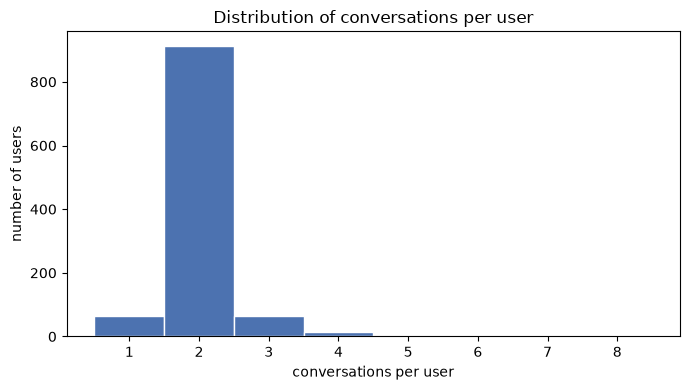

In [ ]:
# (b) Conversations per user.
convs_per_user = conv.groupby("user_id").size()
print(convs_per_user.describe())

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(convs_per_user.values, bins=range(1, int(convs_per_user.max()) + 2),
        align="left", color="#4C72B0", edgecolor="white")
ax.set_xlabel("conversations per user")
ax.set_ylabel("number of users")
ax.set_title("Distribution of conversations per user")
plt.tight_layout()
plt.show()

count    2155.000000
mean        7.915545
std         4.671404
min         2.000000
25%         4.000000
50%         8.000000
75%        10.000000
max        32.000000
Name: n_messages, dtype: float64


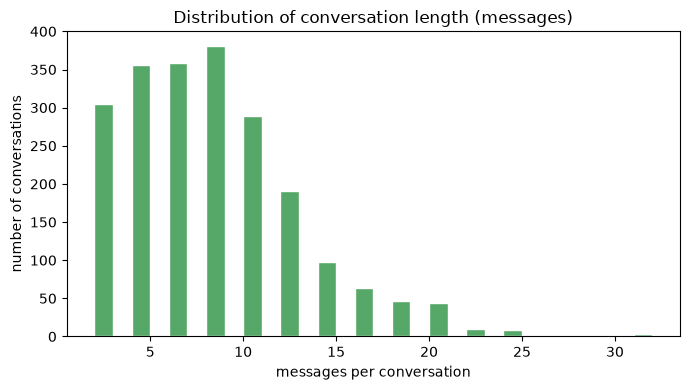

In [ ]:
# (c) Conversation length, in messages (turns).
print(conv["n_messages"].describe())

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(conv["n_messages"].values, bins=30, color="#55A868", edgecolor="white")
ax.set_xlabel("messages per conversation")
ax.set_ylabel("number of conversations")
ax.set_title("Distribution of conversation length (messages)")
plt.tight_layout()
plt.show()

count    2155.000000
mean        4.721114
std         3.835486
min         0.000000
25%         2.000000
50%         4.000000
75%         7.000000
max        32.000000
Name: n_thought_annotations, dtype: float64


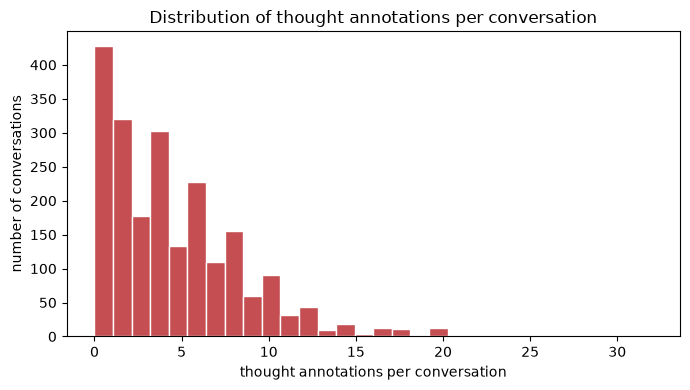

In [ ]:
# (d) Thought annotations (reasons + reactions) per conversation.
print(conv["n_thought_annotations"].describe())

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(conv["n_thought_annotations"].values, bins=30, color="#C44E52", edgecolor="white")
ax.set_xlabel("thought annotations per conversation")
ax.set_ylabel("number of conversations")
ax.set_title("Distribution of thought annotations per conversation")
plt.tight_layout()
plt.show()

In [ ]:
# (e) Reaction-category (5) and reason-category (7) distributions.
# NOTE (methods): labels are AS RELEASED and differ from the README/paper. For example the
# README's `clarification_and_error_correction` and a literal `other` do not appear, while
# `partial_satisfaction` (reaction) and `social_and_others` (reason) do. We report observed.
reason_counts = pd.Series(Counter(reason_labels)).sort_values(ascending=False)
reaction_counts = pd.Series(Counter(reaction_labels)).sort_values(ascending=False)

reason_table = pd.DataFrame({
    "count": reason_counts,
    "proportion": (reason_counts / reason_counts.sum()).round(4),
})
reaction_table = pd.DataFrame({
    "count": reaction_counts,
    "proportion": (reaction_counts / reaction_counts.sum()).round(4),
})
print(f"Reason categories (user turns): {len(reason_table)}")
print(reason_table)
print(f"\nReaction categories (assistant turns): {len(reaction_table)}")
print(reaction_table)

Reason categories (user turns): 7
                                   count  proportion
task_motivation                     1680      0.3735
task_continuation                    954      0.2121
context_grounding_and_constraints    593      0.1318
content_expectation                  515      0.1145
social_and_others                    482      0.1072
style_expectation                    229      0.0509
task_reorientation                    45      0.0100

Reaction categories (assistant turns): 5
                      count  proportion
explicit_affirmation   4099      0.7222
content_relevance       682      0.1202
presentation_style      361      0.0636
scope_fit               342      0.0603
partial_satisfaction    192      0.0338


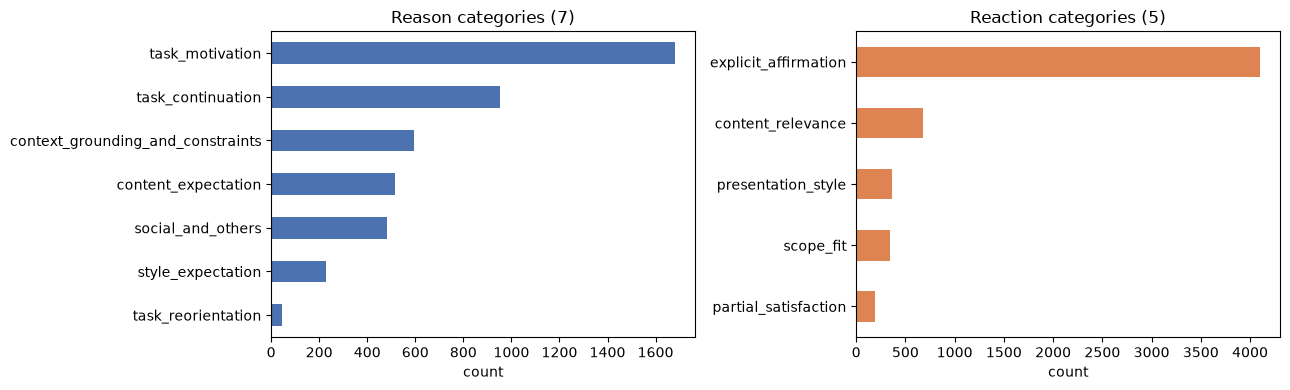

In [ ]:
# (e cont.) Bar charts for the two label vocabularies.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
reason_counts.iloc[::-1].plot.barh(ax=axes[0], color="#4C72B0")
axes[0].set_title(f"Reason categories ({len(reason_counts)})")
axes[0].set_xlabel("count")
reaction_counts.iloc[::-1].plot.barh(ax=axes[1], color="#DD8452")
axes[1].set_title(f"Reaction categories ({len(reaction_counts)})")
axes[1].set_xlabel("count")
plt.tight_layout()
plt.show()

Source LLMs: 20 distinct (expected ~20)
model_name
GPT-5.4                   337
Gemini 3.1 Pro Preview    313
Grok 4.20                 210
Claude Opus 4.6           141
Claude Sonnet 4.6         134
MiniMax M2.7              100
Qwen3.6 Plus               72
Kimi K2.5                  71
gpt-oss-120b               70
GPT-4o-mini                69
Gemini 3 Flash Preview     69
Gemma 4 26B A4B            69
MiMo-V2-Pro                67
GLM 5                      64
Step 3.5 Flash             64
Grok 4.1 Fast              63
Llama 3.3 70B Instruct     62
Mistral Small 4            61
Claude Haiku 4.5           60
DeepSeek V3.2              59
Name: count, dtype: int64


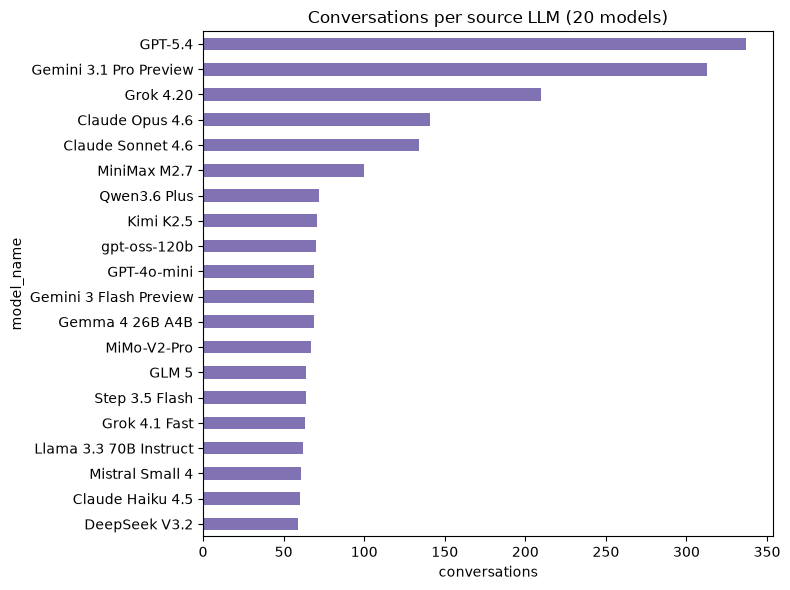

In [ ]:
# (f) Breakdown by source LLM (model_name).
model_counts = conv["model_name"].value_counts()
print(f"Source LLMs: {model_counts.shape[0]} distinct (expected ~20)")
print(model_counts)

fig, ax = plt.subplots(figsize=(8, 6))
model_counts.iloc[::-1].plot.barh(ax=ax, color="#8172B3")
ax.set_title(f"Conversations per source LLM ({model_counts.shape[0]} models)")
ax.set_xlabel("conversations")
plt.tight_layout()
plt.show()

In [ ]:
# (f cont.) Topic domains. The rebuild notes list model/provider and survey purposes but
# no explicit "domain" field, so we DETECT a domain-like column rather than assume one:
# a conversation-level field with a small number of distinct values (~7).
candidate_names = ["domain", "topic", "topic_domain", "category", "task_type", "task_domain", "subject"]
present = [c for c in candidate_names if c in ds.column_names]

domain_field = None
for c in present:
    vals = pd.Series([rec.get(c) for rec in ds])
    if 2 <= vals.nunique() <= 15:
        domain_field = c
        break

if domain_field is None:
    print("No explicit topic-domain field found among:", candidate_names)
    print("Available fields:", ds.column_names)
    print("--> The '7 topic domains' breakdown needs the correct field name; flag for follow-up.")
else:
    domain_counts = pd.Series([rec.get(domain_field) for rec in ds]).value_counts()
    print(f"Using domain field: '{domain_field}'  ({domain_counts.shape[0]} distinct values)")
    print(domain_counts)
    fig, ax = plt.subplots(figsize=(8, 4))
    domain_counts.iloc[::-1].plot.barh(ax=ax, color="#937860")
    ax.set_title(f"Conversations per topic domain ('{domain_field}', {domain_counts.shape[0]})")
    ax.set_xlabel("conversations")
    plt.tight_layout()
    plt.show()

No explicit topic-domain field found among: ['domain', 'topic', 'topic_domain', 'category', 'task_type', 'task_domain', 'subject']
Available fields: ['id', 'messages', 'model_name', 'model_provider', 'created_at', 'updated_at', 'task_summary', 'task_expectation', 'survey_answers']
--> The '7 topic domains' breakdown needs the correct field name; flag for follow-up.


In [ ]:
# (g) SUPERVISION-SPARSITY FLAGS  <-- bears on the open supervision decision.
# Flag conversations that are (i) very short or (ii) carry only a single reaction signal,
# and report each as an absolute count and a fraction of the corpus.
n = len(conv)

very_short = conv[conv["n_user_turns"] <= 1]        # a single user->assistant exchange
no_reaction = conv[conv["n_reactions"] == 0]         # no assistant reaction signal at all
single_reaction = conv[conv["n_reactions"] == 1]     # exactly one reaction signal
sparse_signal = conv[conv["n_reactions"] <= 1]       # union of the two above
short_or_sparse = conv[(conv["n_user_turns"] <= 1) | (conv["n_reactions"] <= 1)]

def frac(df):
    return f"{len(df):,} ({len(df) / n:.1%})"

print(f"Corpus: {n:,} conversations")
print(f"  very short (<=1 user turn)        : {frac(very_short)}")
print(f"  no reaction signal (0 reactions)  : {frac(no_reaction)}")
print(f"  single reaction signal (==1)      : {frac(single_reaction)}")
print(f"  sparse reaction (<=1 reaction)    : {frac(sparse_signal)}")
print(f"  very short OR sparse reaction     : {frac(short_or_sparse)}")

Corpus: 2,155 conversations
  very short (<=1 user turn)        : 305 (14.2%)
  no reaction signal (0 reactions)  : 294 (13.6%)
  single reaction signal (==1)      : 420 (19.5%)
  sparse reaction (<=1 reaction)    : 714 (33.1%)
  very short OR sparse reaction     : 724 (33.6%)


## Empirical takeaways

1. **Reaction signal is sparse.** Per the rebuild notes ~65% of assistant turns carry a reaction and ~52% of user turns carry a reason; the per-conversation histogram (d) shows how unevenly that signal is concentrated.
2. **A real slice of the corpus is short or single-signal.** The sparsity flags (g) quantify the conversations most exposed to the supervision-sparsity risk — these are the ones a reaction-supervised objective would learn almost nothing from.
3. **Conversations effectively always end on an assistant turn** (user vs. assistant turn counts are ~equal), so turn-pairing is safe but the final assistant turn never has a following reason.
4. **Users and source LLMs are both spread thin.** Per-user conversation counts (b) are right-skewed — most users contribute only one or a few conversations — and ~20 source LLMs each cover a modest share (f).
5. **Topic-domain coverage is conditional on locating the right field** (f) — if none is auto-detected, the 7-domain breakdown is pending a field name.